### Mini-Projeto 5

## Modelagem Estatística e Interpretação de Resultados na Análise de Churn

**1. Importação das Bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown

In [2]:
# Configurações para melhorar a visualização
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [3]:
%reload_ext watermark
%watermark -a "Leonardo da Silva Neves"

Author: Leonardo da Silva Neves



In [4]:
%watermark --iversions

IPython    : 9.11.0
matplotlib : 3.10.8
numpy      : 2.3.5
pandas     : 2.3.3
plotly     : 6.6.0
seaborn    : 0.13.2
statsmodels: 0.14.6



In [5]:
#2. Definição do Problema de Negócio
display(Markdown("""
##2.1. Problema de Negócio

A **GreenFox**, um empresa fictícia de telecomunicações, está enfrentando uma taxa de cancelamento de serviços (churn) acima da média do setor.
A perda de clientes não só impacta a receita recorrente, mas também gera custos elevados com a aquisição de novos clientes para substituir os que
foram perdidos.

A diretoria precisa de respostas claras e baseadas em dados para a seguinte pergunta: "Quais são os principais fatores que levam nossos clientes a cancelar o serviço?"

    - Queremos compreender a relação entre variáveis -> Modelagem Estatística
    - Se quisermos prever o cancelamento (churn) -> Modelagem Preditiva

##2.2. Objetivo do Projeto

Este projeto visa utilizar a modelagem estatística para analisar dados do cliente e atingir os seguintes desafios:

 1. **Identificar os Fatores-Chave**: Determinar quais variáveis (como tipo de contrato, tempo de fidelidade, valor de fatura) têm impacto estatisticamente
 significativo na probabilidade de um cliente cancelar o serviço.
 2. **Quantificar o Impacto**: Medir quão forte é a influência de cada fator no risco de churn.
 3. **Gerar Recomendações**: Traduzir os resultados da análise estatística em recomendações de negócio acionáveis para a criação de estratégias de retenção de
 clientes.

O modelos escolhido para está análise será a Regressão Logística, pois o nosso objetivo é entender a relação entre diversas variáveis e uma variável de resultado binária (Churn: Sim ou Não).
"""))


##2.1. Problema de Negócio

A **GreenFox**, um empresa fictícia de telecomunicações, está enfrentando uma taxa de cancelamento de serviços (churn) acima da média do setor.
A perda de clientes não só impacta a receita recorrente, mas também gera custos elevados com a aquisição de novos clientes para substituir os que
foram perdidos.

A diretoria precisa de respostas claras e baseadas em dados para a seguinte pergunta: "Quais são os principais fatores que levam nossos clientes a cancelar o serviço?"

    - Queremos compreender a relação entre variáveis -> Modelagem Estatística
    - Se quisermos prever o cancelamento (churn) -> Modelagem Preditiva

##2.2. Objetivo do Projeto

Este projeto visa utilizar a modelagem estatística para analisar dados do cliente e atingir os seguintes desafios:

 1. **Identificar os Fatores-Chave**: Determinar quais variáveis (como tipo de contrato, tempo de fidelidade, valor de fatura) têm impacto estatisticamente
 significativo na probabilidade de um cliente cancelar o serviço.
 2. **Quantificar o Impacto**: Medir quão forte é a influência de cada fator no risco de churn.
 3. **Gerar Recomendações**: Traduzir os resultados da análise estatística em recomendações de negócio acionáveis para a criação de estratégias de retenção de
 clientes.

O modelos escolhido para está análise será a Regressão Logística, pois o nosso objetivo é entender a relação entre diversas variáveis e uma variável de resultado binária (Churn: Sim ou Não).


**3. Extração dos Dados**

In [6]:
# Função para gerar dados fictícios mais coerentes para a análise
def gera_dados_churn(num_clientes = 2000):

    """
    Gera uma DataFrame de dados fictícios de clientes de uma empresa de telecomunicações.
    """

    # Para reprodutibilidade
    np.random.seed(42)

    # Variáveis
    fidelidade_meses = np.random.randint(1, 73, size = num_clientes)
    tipo_contrato_opts = ['Mensal', 'Anual', 'Dois anos']
    contrato_probs = [0.6, 0.25, 0.15]
    tipo_contrato = np.random.choice(tipo_contrato_opts, size = num_clientes, p = contrato_probs)
    servico_internet_opts = ['Fibra Óptica', 'DSL', 'Não']
    internet_probs = [0.55, 0.35, 0.10]
    servico_internet = np.random.choice(servico_internet_opts,size = num_clientes, p = internet_probs)

    fatura_base = {
        'Mensal': np.random.normal(60,20),
        'Anual': np.random.normal(70, 25),
        'Dois anos': np.random.normal(80, 25)
    }

    fatura_mensal = [fatura_base[c] +fidelidade_meses[i] * 0.2 + np.random.normal(0, 5) for i, c in enumerate(tipo_contrato)]
    fatura_mensal = np.clip(fatura_mensal, 20, 120)

    # Lógica para a probabilidade de Churn
    # Clientes com contrato mensal, baixa fidelidade e fatura alta têm maior chance de churn
    prob_churn_log = -2.5 # Intercepto base (tendência a não cancelar)
    prob_churn_log += -0.05 * fidelidade_meses # Mais fidelidade, maior chance
    prob_churn_log += [3.0 if c == 'Mensal' else -1.5 if c == 'Anual' else -2.5 for c in tipo_contrato]
    prob_churn_log += [0.8 if s == 'Fibra Óptica' else -0.5 for s in servico_internet] # Fibra tende a ter mais churn (talvez pelo preço)
    prob_churn_log += 0.03 * fatura_mensal # Fatura mais alta, mais chance

    # Converter log_odds para probabilidade usando  a função signoide
    prob_churn = 1/ (1 + np.exp(-prob_churn_log))

    # Gerar o resultado de churn com base na probabilidade
    churn = np.random.binomial(1, prob_churn)

    df = pd.DataFrame({
    'ID_Cliente': range(1, num_clientes + 1),
    'Fidelidade_Meses': fidelidade_meses,
    'Tipo_Contrato': tipo_contrato,
    'Servico_Internet': servico_internet,
    'Fatura_Mensal': fatura_mensal,
    'Churn': churn
    })

    return df

In [7]:
# Gera os dados
df_churn = gera_dados_churn()

In [8]:
display(Markdown("### Amostra dos Dados Gerados"))
df_churn.head()

### Amostra dos Dados Gerados

,ID_Cliente,Fidelidade_Meses,Tipo_Contrato,Servico_Internet,Fatura_Mensal,Churn
0,1,52,Anual,Fibra Óptica,36.5724,0
1,2,15,Dois anos,Fibra Óptica,45.2871,0
2,3,72,Mensal,Fibra Óptica,101.0033,1
3,4,61,Mensal,Fibra Óptica,103.3314,1
4,5,21,Mensal,DSL,94.0969,1


**4. Análise Exploratória dos Dados**

In [9]:
# Informações Gerais do DataFrame
display(Markdown("### Informações Gerais do DataFrame"))
display(df_churn.info())

### Informações Gerais do DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Cliente        2000 non-null   int64  
 1   Fidelidade_Meses  2000 non-null   int64  
 2   Tipo_Contrato     2000 non-null   object 
 3   Servico_Internet  2000 non-null   object 
 4   Fatura_Mensal     2000 non-null   float64
 5   Churn             2000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 93.9+ KB


None

In [10]:
# Resumo Estatístico
display(Markdown("### Resumo Estatístico"))
display(df_churn.describe())

### Resumo Estatístico

,ID_Cliente,Fidelidade_Meses,Fatura_Mensal,Churn
count,2000.0000,2000.0000,2000.0000,2000.0000
mean,1000.5000,35.6825,75.3201,0.4905
std,577.4946,20.8430,27.5079,0.5000
min,1.0000,1.0000,24.9216,0.0000
25%,500.7500,17.0000,45.0201,0.0000
50%,1000.5000,35.0000,90.6543,0.0000
75%,1500.2500,54.0000,98.5286,1.0000
max,2000.0000,72.0000,119.2712,1.0000


In [11]:
# Resumo Estatístico
display(Markdown("### Resumo Estatístico"))
display(df_churn.describe(include = 'object'))

### Resumo Estatístico

,Tipo_Contrato,Servico_Internet
count,2000,2000
unique,3,3
top,Mensal,Fibra Óptica
freq,1186,1114


**4.1. Gráfico de Taxa de Churn Geral**

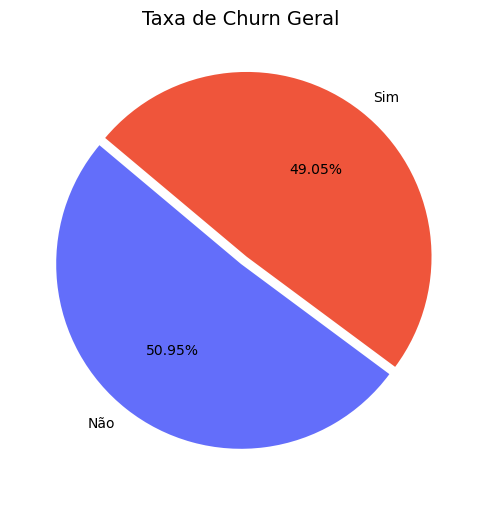

In [12]:
# Gráfico - Versão Estatísca

# Conta os valores da coluna 'Churn'
churn_counts = df_churn['Churn'].value_counts().rename(index = {1: 'Sim', 0: 'Não'})

# Definindo as cores equivalentes ao gráfico original
cores = ['#636EFA', '#EF553B']

# Cria um gráfico de pizza com duas casa decimais
plt.figure(figsize = (6, 6))
plt.pie(
    churn_counts.values,
    labels = churn_counts.index,
    autopct = '%1.2f%%', # <-- duas casas decimais
    startangle = 140,
    colors = cores,
    explode = [0.05 if label == 'Sim' else 0 for label in churn_counts.index]
)
plt.title('Taxa de Churn Geral', fontsize = 14)
plt.show()

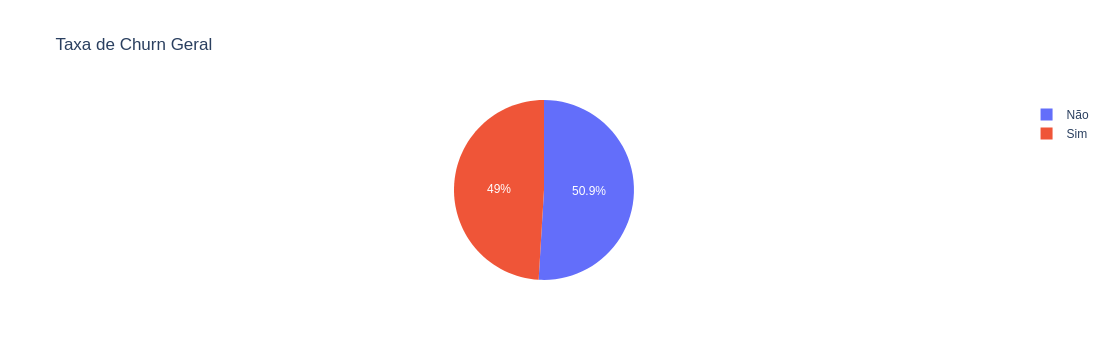

In [13]:
# Gráfico Versão Interativa

# Coleta a contagem por categoria
churn_counts = df_churn['Churn'].value_counts()

# Cria o gráfico
fig_pie = px.pie(
    values = churn_counts.values,
    names = churn_counts.index.map({1: 'Sim', 0: 'Não'}),
    title = 'Taxa de Churn Geral',
    color = churn_counts.index.map({1:'Sim', 0: 'Não'}),
    color_discrete_map = {'Sim': '#EF5538', 'Não': '#636EFA'})
fig_pie.show()

In [14]:
# Calculando a taxa de Churn
churn_counts = df_churn['Churn'].value_counts()
numerador = churn_counts.get(1, churn_counts.get('Sim', churn_counts.get(True, 0)))
taxa = 100 * numerador / len(df_churn)

display(Markdown(f"""
A taxa de Churn geral na base de dados é  de **{taxa:.2f}%**.
Este é o nosso principal indicador a ser analisado.
"""))


A taxa de Churn geral na base de dados é  de **49.05%**.
Este é o nosso principal indicador a ser analisado.


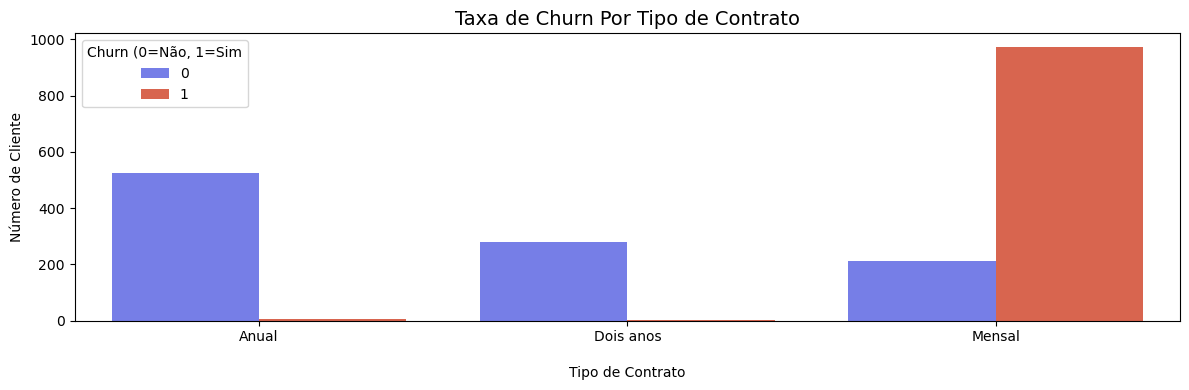

In [15]:
# Gráfico Versão Estática
plt.figure(figsize = (12, 4))

# Criando o gráfico de barras agrupadas
sns.countplot(data = df_churn,
              x = 'Tipo_Contrato',
              hue = 'Churn',
              palette = {0: '#636EFA', 1: '#EF5538'})

plt.title('Taxa de Churn Por Tipo de Contrato', fontsize = 14)
plt.xlabel('\nTipo de Contrato')
plt.ylabel('Número de Cliente')
plt.legend(title = 'Churn (0=Não, 1=Sim')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

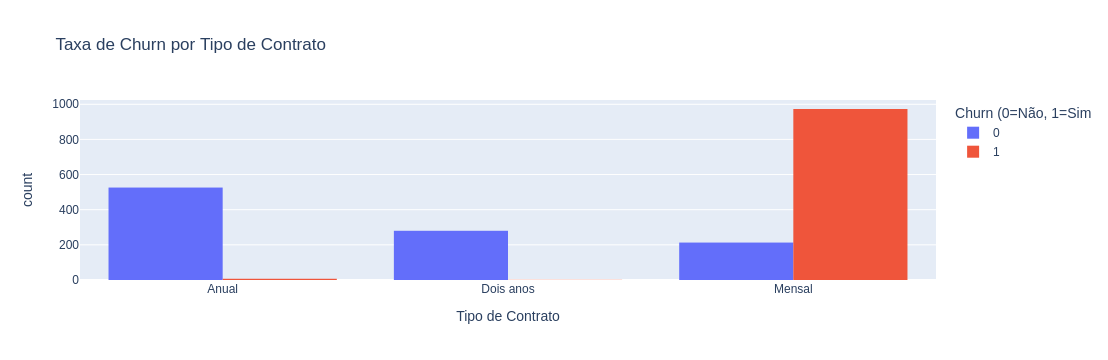

In [16]:
# Histograma
dsa_fig_bar_contrato = px.histogram(df_churn,
                                    x = 'Tipo_Contrato',
                                    color = 'Churn',
                                    barmode = 'group',
                                    title = 'Taxa de Churn por Tipo de Contrato',
                                    labels = {'Tipo_Contrato': 'Tipo de Contrato', 'Churn': 'Churn (0=Não, 1=Sim'})
dsa_fig_bar_contrato.show()

In [17]:
display(Markdown("""
**Insight:** A visualização é clara: clientes com **contrato mensal** têm uma propensão ao churn dransticamente maior em comparação com o clientes de contratos anuais ou de dois anos."""))
                 


**Insight:** A visualização é clara: clientes com **contrato mensal** têm uma propensão ao churn dransticamente maior em comparação com o clientes de contratos anuais ou de dois anos.

**4.3. Gráfico da Distribuição da Fidelidade (em Meses) Por Churn**

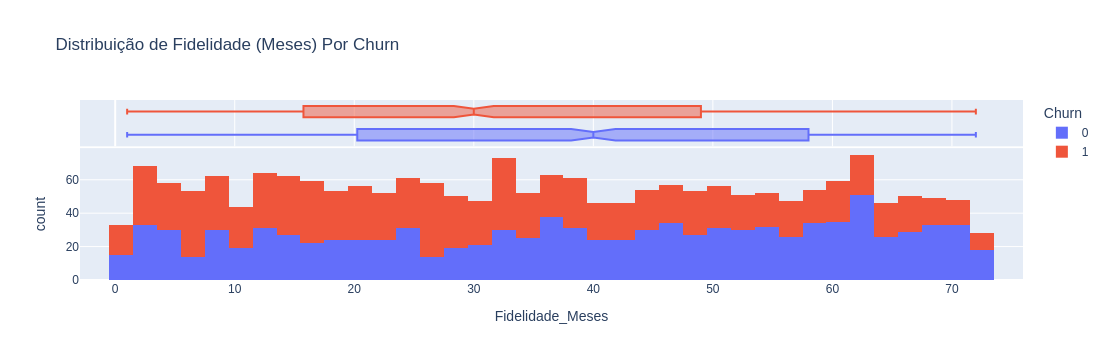

In [18]:
# Análise de Fidelidade (Tenure)
hist_fidelidade = px.histogram(df_churn,
                              x = 'Fidelidade_Meses',
                              color = 'Churn',
                              marginal = 'box',
                              title = 'Distribuição de Fidelidade (Meses) Por Churn',
                              labels = {'Fidelidade_Meses": "Meses de Fidelidade'})
hist_fidelidade.show()

In [19]:
display(Markdown("""
**Insight**: Clientes que cancelam o serviço (Churn=1) estão mais conceitrados nos primeiros meses de contrato.
A mediana de fidelidade para clientes que cancelam é muito menor do que para os que permanecem. Isso indica que o início da
jornada do cliente é um periodo crítico para a retenção."""))


**Insight**: Clientes que cancelam o serviço (Churn=1) estão mais conceitrados nos primeiros meses de contrato.
A mediana de fidelidade para clientes que cancelam é muito menor do que para os que permanecem. Isso indica que o início da
jornada do cliente é um periodo crítico para a retenção.

**4.4. Gráfico de Distribuição da Fatura Mensal po Churn**

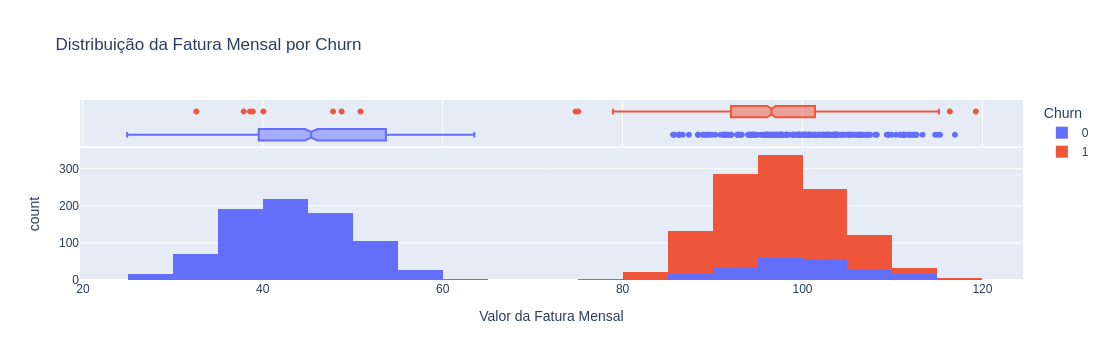

In [21]:
# Gráfico - Versão Interativa

# Análise por fatura mensal
hist_fatura = px.histogram(df_churn,
                           x = 'Fatura_Mensal',
                           color = 'Churn',
                           marginal = 'box',
                           title = 'Distribuição da Fatura Mensal por Churn',
                           labels = {'Fatura_Mensal': 'Valor da Fatura Mensal'})
hist_fatura.show()

In [22]:
display(Markdown("""
**Insight**: Clientes com fatura mensal mais altas tendem a apresentar uma taxa de churn maior.
A mediana da fatura para clientes que cancelam é notavelmente superior."""))


**Insight**: Clientes com fatura mensal mais altas tendem a apresentar uma taxa de churn maior.
A mediana da fatura para clientes que cancelam é notavelmente superior.

**5. Preparação dos Dados Para a Modelagem Estatística**

In [24]:
# Dados originais
df_churn.head()

,ID_Cliente,Fidelidade_Meses,Tipo_Contrato,Servico_Internet,Fatura_Mensal,Churn
0,1,52,Anual,Fibra Óptica,36.5724,0
1,2,15,Dois anos,Fibra Óptica,45.2871,0
2,3,72,Mensal,Fibra Óptica,101.0033,1
3,4,61,Mensal,Fibra Óptica,103.3314,1
4,5,21,Mensal,DSL,94.0969,1


In [25]:
# Categorias da variável
df_churn.Tipo_Contrato.value_counts()

Tipo_Contrato
Mensal       1186
Anual         533
Dois anos     281
Name: count, dtype: int64

In [26]:
# Categorias da variável
df_churn.Servico_Internet.value_counts()

Servico_Internet
Fibra Óptica    1114
DSL              690
Não              196
Name: count, dtype: int64

In [27]:
# Preparando os dados
# Converter variáveis categóricas em variáveis dummy (0 ou 1)
# Adicionando o parâmetro dtype=int para garantir que as  novas colunas sejam numéricas
df_model = pd.get_dummies(df_churn, columns = ['Tipo_Contrato', 'Servico_Internet'], drop_first = True, dtype = int)

**Variáveis dummy** (ou variáveis indicadoras) são variáveis numéricas criadas para representer categorias em modelos estatísticos ou de Machine Learning. Elas transformam dados qualitativos (como "genero", "estado civil", "região") em valores numéricos, geralmente 0 e 1, permitindo que algoritmos matemáticos consigam processá-los.

Assim, o modelo consegue interpretar diferenças entre grupos sem precisar lidar com textos. As variáveis dummy são uma forma de codificar categorias em números binários, facilitando análises estatísticas e predições. A técnica de criação de variáveis dummy é chamada de **One-Hot-Encoding**.

In [28]:
# Dados originais
df_churn.head()

,ID_Cliente,Fidelidade_Meses,Tipo_Contrato,Servico_Internet,Fatura_Mensal,Churn
0,1,52,Anual,Fibra Óptica,36.5724,0
1,2,15,Dois anos,Fibra Óptica,45.2871,0
2,3,72,Mensal,Fibra Óptica,101.0033,1
3,4,61,Mensal,Fibra Óptica,103.3314,1
4,5,21,Mensal,DSL,94.0969,1


In [29]:
# Dados processados
df_model.head()

,ID_Cliente,Fidelidade_Meses,Fatura_Mensal,Churn,Tipo_Contrato_Dois anos,Tipo_Contrato_Mensal,Servico_Internet_Fibra Óptica,Servico_Internet_Não
0,1,52,36.5724,0,0,0,1,0
1,2,15,45.2871,0,1,0,1,0
2,3,72,101.0033,1,0,1,1,0
3,4,61,103.3314,1,0,1,1,0
4,5,21,94.0969,1,0,1,0,0


In [30]:
# Resumo dos dodos
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_Cliente                     2000 non-null   int64  
 1   Fidelidade_Meses               2000 non-null   int64  
 2   Fatura_Mensal                  2000 non-null   float64
 3   Churn                          2000 non-null   int64  
 4   Tipo_Contrato_Dois anos        2000 non-null   int64  
 5   Tipo_Contrato_Mensal           2000 non-null   int64  
 6   Servico_Internet_Fibra Óptica  2000 non-null   int64  
 7   Servico_Internet_Não           2000 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 125.1 KB


In [32]:
# Definir as variáveis
# Variável dependente (o que queremos prever)
y = df_model['Churn']

In [33]:
# Variáveis independêntes (as que usamos para prever)
# Excluímos o ID do cliente e a variável alvo original
X = df_model.drop(['ID_Cliente', 'Churn'], axis = 1)

In [34]:
# Adicionar uma constante (intercepto) ao modelo, exigido pela biblioteca statsmodels
X = sm.add_constant(X)

In [35]:
display(Markdown("### Amostra dos Dados (X) Preparados Para o Modelo"))
display(X.head())

### Amostra dos Dados (X) Preparados Para o Modelo

,const,Fidelidade_Meses,Fatura_Mensal,Tipo_Contrato_Dois anos,Tipo_Contrato_Mensal,Servico_Internet_Fibra Óptica,Servico_Internet_Não
0,1.0000,52,36.5724,0,0,1,0
1,1.0000,15,45.2871,1,0,1,0
2,1.0000,72,101.0033,0,1,1,0
3,1.0000,61,103.3314,0,1,1,0
4,1.0000,21,94.0969,0,1,0,0


In [36]:
display(Markdown("### Amostra dos Dados (y) Preparados Para o Modelo"))
display(y.head())

### Amostra dos Dados (y) Preparados Para o Modelo

0    0
1    0
2    1
3    1
4    1
Name: Churn, dtype: int64

**6. Modelagem Estatística**

In [38]:
display(Markdown("Vamos construir um modelo para quantificar o impacto de cada variável na probabilidade de churn."))

Vamos construir um modelo para quantificar o impacto de cada variável na probabilidade de churn.

In [39]:
# Criamos o modelo
modelo = sm.Logit(y, X)

In [40]:
type(modelo)

statsmodels.discrete.discrete_model.Logit

In [41]:
# Treinamento do modelo
modelo_treinado = modelo.fit()

Optimization terminated successfully.
         Current function value: 0.245933
         Iterations 10


In [42]:
# Exibir o resumo completo do modelo
display(Markdown("### Resultado do Modelo de Regressão Logística"))
modelo_treinado.summary()

### Resultado do Modelo de Regressão Logística

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1993
Method:                           MLE   Df Model:                            6
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.6451
Time:                        11:19:37   Log-Likelihood:                -491.87
converged:                       True   LL-Null:                       -1385.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -5.2263      0.714     -7.316      0.000      -6.627      -3.826
Fidelidade_Meses                 -0.0556      0.006     -9.883      0.000      -0.067      -0.045
Fatura_Mensal                     0.0316      0.016      2.004      0.045       0.001       0.062
Tipo_Contrato_Dois anos          -1.2741      1.075     -1.185      0.236      -3.382       0.834
Tipo_Contrato_Mensal              5.2739      0.934      5.647      0.000       3.443       7.104
Servico_Internet_Fibra Óptica     1.4550      0.180      8.091      0.000       1.103       1.807
Servico_Internet_Não              0.2096      0.264      0.793      0.428      -0.308       0.727
=================================================================================================
"""

O resultado acima contém informações ricas sobre o modelo. Vamos focar nos pontos mais importantes para o negócio:

 1. **Coeficientes (coef):** Mostram a direção do impacto. Um coeficiente positivo aumenta a chance de churn, enquanto um negativo a diminui.

 2. **Valor-p (P>|z|):** Indica a significância estatística de cada variável. Um valor-p baixo (geralmente < 0.05) significa que o efeito da variável é real e não apenas uma  coincidência na amostra.

 3. **Pseudo R-squ.:** Similar  ao R² na regressão linear, indica a proporção da "variância" da variável dependente que é explicada pelo modelo. Um valor de 0.645 (ou 65%) é considerado um bom ajuste para esse tipo de modelo.

Para facilitar a interpretação, vamos calcular a **Razão de Chances (Odds Ratio)**, que nos diz como as chances de churn mudam com o aumento de uma unidade na  variável independente.

A Razão de Chances (ou Odds Radio) é uma medida usada para comprar a probabilidade de um evento ocorrer entre dois grupos. Ela é muito comum em estatística e modelos como a regressão logística.

De forma simples, a "chance" (odds) de um evento é a razão entre a probabilidade de ele acontecer e a probabilidade de não acontecer. Por exemplo, se a probabilidade de uma cliente comprar um produto é 0,8 (80%), então a chance é 0,8/0,2 = 4. Isso quer dizer que a chance de comprar é quadro vezes maior que a de não comprar.

In [43]:
# Calcular e exibir as razões de chance (Odds Ratios)
params = modelo_treinado.params
conf = modelo_treinado.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
conf = np.exp(conf)
display(Markdown("### Tabela de Razão de Chances (Odds Ratio)"))
display(conf)

### Tabela de Razão de Chances (Odds Ratio)

,2.5%,97.5%,Odds Ratio
const,0.0013,0.0218,0.0054
Fidelidade_Meses,0.9355,0.9564,0.9459
Fatura_Mensal,1.0007,1.0644,1.0321
Tipo_Contrato_Dois anos,0.0340,2.3019,0.2797
Tipo_Contrato_Mensal,31.2962,1217.3069,195.1849
Servico_Internet_Fibra Óptica,3.0118,6.0947,4.2844
Servico_Internet_Não,0.7347,2.0697,1.2331


** Interpretação da Razão de Chances para o Negócio:**

**1. const(intercepto)**

O valor 0.0054 representa a chance base de churn quando todas as outras variáveis são zero. Ele por si só não tem interpretação prática relevante e serve como ponto de partida do modelo.

**2. Fidelidade_Meses (0.9459)**

O odds ratio é menor que 1, o que indica um efeito protetor: quanto mais meses de fidelidade, menor a chance de churn. Cada mês adicional reduz em cerca de (1 - 0.9459) x 100 = 5,4% a chance de o cliente cancelar.

**3. Fatura_Mensal (1.0321)**

Um valor ligeiramente acima de 1 mostra que quanto maior a fatura mensal, maior a chance de churn. A cada aumento unitário (por exemplo, R$1), a chance cresce em torno de 3,2%. Isso pode indicar insatisfação com preços mais altos.

**4. Tipo_Contrato_Dois anos (0.2797)**

O valor é menor que 1, o que significa que clientes com contratos de dois anos têm menor probabilidade de cancelar comparados ao grupo de referência (por exemplo "Contrato de um ano"). Isso sugere que contratos longos retêm melhor os clientes.

**5. Tipo_Contrato_Mensal (195.1849)**

Um valor muito alto mostra que clientes com contrato mensal têm probabilidade muito maior de cancelar, cerca de 195 vezes maior do que o grupo de referência. Isso é típico: contratos mensais são mais flexíveis e os clientes saem mais facilmente.

**6. Servico_Internet_Fibra Óptica (4.2844)**

Clientes com fibra óptica têm 4,28 vezez mais chances de churn que os que usam outro tipod e internet (como DSL, que seria o grupo base). Pode indicar que este grupo é mais exigente ou sensível a falhas de serviço.

**7. Servico_Internet_Não (1.2331)**

Cliente sem serviço de internet têm uma chance 23% maior de churn em relação ao grupo base, mas o intervalo de confiança (0.73 a 2.06) inclui 1, o que sugere baixa significância estatística, ou seja, o efeito pode não ser real.

Em resumo:

 - Fidelidade e contrato de longo prazo reduzem churn.
 - Fatura alta, contrato mensal e fibra óptica aumentam churn.
 - O odds ratio mostra o tamanho e a direção do efeito de cada variável sobre a probabilidade de cancelamento.

**8. Relatório Final - Conclusão e Recomendações Estratégicas**

In [55]:
display(Markdown("""
# Relatório Final: Conclusões e Recomendações Estratégicas

## Cocluções

A Análise estatística revelou, com auto grau de confiança, os principais impulsionadores de churn de clientes da empresa de telecomunição. Os
resultados do modelo de regressão logística que o cancelamento está fortemente associado a alguns fatores comportamentais e contratuais especificos.
O perfil de cliente com **alto risco de churn** é: **cliente recente**, **com contrato mensal**, **fatura elevada** e **serviço de fibra óptica**.

Os fatores mais significativos, em ordem de impacto, são:

1. **Tipo de Contrato:** Clientes com contratos mensais apresentam um risco de cancelamento aproximadamente **195 vezes maior** em relação aos de
contratos mais longos. Contratos de dois anos são o principal fator de proteção.
2. **Tempo de Fidelidade:** Cada mês adicional de permanência reduz a chance de churn em cerca de **5%**, mostrando que os primeiros meses são cruciais
para a retenção.
3. **Valor da Fatura Mensal:** O aumento no valor da fatura mensal eleva o risco de churn em aproximadamente **3% por unidade monetária**, sugeringo
sensibilidade a preço.
4. **Tipo de Serviço de Internet:** O serviço de **Fibra Óptica** aumenta em cerca de **4 vezes** a chance de cancelamento em comparação com com o DSL,
possivelmente devido a expectativas não atendidas ou à percepção de custo elevado.

## Recomendações Acionáveis

Com base nessas conclusões, propõem-se

| Recomendações | Justificativa (Base nos Dados) | Ação Proposta |
| :--- | :--- | :--- |
| **1. Incentivar a migração para contratos de longo prazo** | O contrato mensal está associado a um risco **extremamente alto de churn (aproximadamente 195x.)** | Criar uma campanha promocional para converter clientes mensais em anuais ou bienais, oferecendo incentivos como descontos, bônus de fidelidade ou upgrades temporários de velocidade. |
| **2. Criar um programa de fidelidade para novos clietes** | Cada mês adicional reduz o churn em **5%**. | Implementar um programa de acompanhamento intensivo nos seis primeiros meses, com comunicações personalizadas, suporte proativo e benefícios progressivos para reforçar a satisfação inicial. |
| **3. Revisar a estratégia de preços e valor percebido** | Faturas mais altas aumentam a chance de churn em **3%** por unidade. | Segmentar clientes com faturas elevadas e realizar uma análise de elasticidade de preço. Ajustar pacotes para melhorar o valor percebido (mais benefícios pelo mesmo preço). |
| **4. Investigar o Churn em segmento de fibra óptiva** | Cliente com fibra têm **4x mais chances de cancelar**. | Conduzir uma pesquisa de satisfação e uma análise técnica detalhada sobre a qualidade técnica do serviço e suporte. Identificar causas de insatisfação e agir sobre problemas de performance ou atendimento. |

A adoção dessas recomendações, baseadas em evidências estatísticas sólidas e profissionais, permitirá à **empreas de telecomunicação** reduzir substancialmente o churn,
aumentando a fidelização e fortalecendo sua base de receita recorrente.

### Fim
"""))


# Relatório Final: Conclusões e Recomendações Estratégicas

## Cocluções

A Análise estatística revelou, com auto grau de confiança, os principais impulsionadores de churn de clientes da empresa de telecomunição. Os
resultados do modelo de regressão logística que o cancelamento está fortemente associado a alguns fatores comportamentais e contratuais especificos.
O perfil de cliente com **alto risco de churn** é: **cliente recente**, **com contrato mensal**, **fatura elevada** e **serviço de fibra óptica**.

Os fatores mais significativos, em ordem de impacto, são:

1. **Tipo de Contrato:** Clientes com contratos mensais apresentam um risco de cancelamento aproximadamente **195 vezes maior** em relação aos de
contratos mais longos. Contratos de dois anos são o principal fator de proteção.
2. **Tempo de Fidelidade:** Cada mês adicional de permanência reduz a chance de churn em cerca de **5%**, mostrando que os primeiros meses são cruciais
para a retenção.
3. **Valor da Fatura Mensal:** O aumento no valor da fatura mensal eleva o risco de churn em aproximadamente **3% por unidade monetária**, sugeringo
sensibilidade a preço.
4. **Tipo de Serviço de Internet:** O serviço de **Fibra Óptica** aumenta em cerca de **4 vezes** a chance de cancelamento em comparação com com o DSL,
possivelmente devido a expectativas não atendidas ou à percepção de custo elevado.

## Recomendações Acionáveis

Com base nessas conclusões, propõem-se

| Recomendações | Justificativa (Base nos Dados) | Ação Proposta |
| :--- | :--- | :--- |
| **1. Incentivar a migração para contratos de longo prazo** | O contrato mensal está associado a um risco **extremamente alto de churn (aproximadamente 195x.)** | Criar uma campanha promocional para converter clientes mensais em anuais ou bienais, oferecendo incentivos como descontos, bônus de fidelidade ou upgrades temporários de velocidade. |
| **2. Criar um programa de fidelidade para novos clietes** | Cada mês adicional reduz o churn em **5%**. | Implementar um programa de acompanhamento intensivo nos seis primeiros meses, com comunicações personalizadas, suporte proativo e benefícios progressivos para reforçar a satisfação inicial. |
| **3. Revisar a estratégia de preços e valor percebido** | Faturas mais altas aumentam a chance de churn em **3%** por unidade. | Segmentar clientes com faturas elevadas e realizar uma análise de elasticidade de preço. Ajustar pacotes para melhorar o valor percebido (mais benefícios pelo mesmo preço). |
| **4. Investigar o Churn em segmento de fibra óptiva** | Cliente com fibra têm **4x mais chances de cancelar**. | Conduzir uma pesquisa de satisfação e uma análise técnica detalhada sobre a qualidade técnica do serviço e suporte. Identificar causas de insatisfação e agir sobre problemas de performance ou atendimento. |

A adoção dessas recomendações, baseadas em evidências estatísticas sólidas e profissionais, permitirá à **empreas de telecomunicação** reduzir substancialmente o churn,
aumentando a fidelização e fortalecendo sua base de receita recorrente.

### Fim
